In [22]:
%pip install nselib
%pip install pandas_market_calendars

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
import pandas as pd
from nselib import derivatives
from datetime import datetime, timedelta
from nselib import capital_market

In [27]:
data = derivatives.option_price_volume_data(
    symbol='NIFTY',
    instrument='OPTIDX',
    from_date='01-06-2023',
    to_date='10-06-2023'
)


In [28]:
option_chain = derivatives.nse_live_option_chain('NIFTY')


In [55]:
option_chain


,Fetch_Time,Symbol,Expiry_Date,CALLS_OI,CALLS_Chng_in_OI,CALLS_Volume,CALLS_IV,CALLS_LTP,CALLS_Net_Chng,CALLS_Bid_Qty,...,PUTS_OI,PUTS_Chng_in_OI,PUTS_Volume,PUTS_IV,PUTS_LTP,PUTS_Net_Chng,PUTS_Bid_Qty,PUTS_Bid_Price,PUTS_Ask_Price,PUTS_Ask_Qty
0,06-May-2025 15:30:00,NIFTY,25-Jun-2026,0.000000,0.0,0,0.00,0.0,0.00,0,...,6.333333,0.0,0,0.0,20.05,0.0,1800,1.05,0.0,0
1,06-May-2025 15:30:00,NIFTY,31-Dec-2026,0.000000,0.0,0,0.00,0.0,0.00,0,...,14.666667,0.0,0,0.0,20.05,0.0,750,20.05,0.0,0
2,06-May-2025 15:30:00,NIFTY,24-Dec-2025,0.000000,0.0,0,0.00,0.0,0.00,0,...,56.666667,0.0,0,0.0,17.30,0.0,75,15.00,21.0,75
3,06-May-2025 15:30:00,NIFTY,25-Jun-2026,0.000000,0.0,0,0.00,0.0,0.00,0,...,2.666667,0.0,0,0.0,21.60,0.0,1800,1.05,0.0,0
4,06-May-2025 15:30:00,NIFTY,31-Dec-2026,0.000000,0.0,0,0.00,0.0,0.00,0,...,27.000000,0.0,0,0.0,20.05,0.0,1800,1.25,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
862,06-May-2025 15:30:00,NIFTY,28-Jun-2029,0.000000,0.0,0,0.00,0.0,0.00,0,...,0.000000,0.0,0,0.0,0.00,0.0,1800,2.65,0.0,0
863,06-May-2025 15:30:00,NIFTY,27-Dec-2029,0.000000,0.0,0,0.00,0.0,0.00,0,...,0.000000,0.0,0,0.0,0.00,0.0,1800,2.05,0.0,0
864,06-May-2025 15:30:00,NIFTY,26-Jun-2025,29563.000000,-84.0,338,22.52,8.3,-0.55,525,...,0.000000,0.0,0,0.0,0.00,0.0,0,0.00,0.0,0
865,06-May-2025 15:30:00,NIFTY,24-Dec-2025,1370.666667,11.0,131,11.83,68.2,1.25,75,...,12.000000,0.0,0,0.0,4200.00,0.0,75,4300.00,5800.0,75


In [41]:
%pip install nsetools
from nsetools import Nse
nse = Nse()


[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [42]:
quote = nse.get_index_quote("NIFTY 50")
spot_price = quote['last']
print(f"NIFTY Spot Price: {spot_price}")

NIFTY Spot Price: 24379.6


In [44]:
def get_atm_strike(spot_price, step=50):
    return int(round(spot_price / step) * step)

atm_strike = get_atm_strike(spot_price)
print(f"ATM Strike Price: {atm_strike}")

ATM Strike Price: 24400


In [50]:
def get_short_straddle(option_chain_df, spot_price):
    # Find closest ATM strike
    strikes = option_chain_df['Strike_Price'].unique()
    atm_strike = min(strikes, key=lambda x: abs(x - spot_price))

    # Filter the row with ATM strike
    atm_row = option_chain_df[option_chain_df['Strike_Price'] == atm_strike]

    if atm_row.empty:
        print("ATM strike not found in option chain.")
        return None

    ce_ltp = atm_row['CALLS_LTP'].values[0]
    pe_ltp = atm_row['PUTS_LTP'].values[0]
    net_premium = ce_ltp + pe_ltp

    print(f"ATM Strike: {atm_strike}")
    print(f"Call LTP: {ce_ltp}, Put LTP: {pe_ltp}")
    print(f"Net Premium Collected (Short Straddle): {net_premium}")

    return {
        'strike': atm_strike,
        'ce_ltp': ce_ltp,
        'pe_ltp': pe_ltp,
        'net_premium': net_premium
    }

In [51]:
straddle_info = get_short_straddle(option_chain, spot_price)
if straddle_info:
    print(f"Short Straddle Info: {straddle_info}")

ATM Strike: 24400
Call LTP: 48.95, Put LTP: 112.4
Net Premium Collected (Short Straddle): 161.35000000000002
Short Straddle Info: {'strike': 24400, 'ce_ltp': 48.95, 'pe_ltp': 112.4, 'net_premium': 161.35000000000002}


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_straddle_payoff(strike, net_premium):
    spot_prices = np.arange(strike - 500, strike + 500, 10)
    payoff = []

    for s in spot_prices:
        if s < strike:
            pnl = net_premium - (strike - s)
        elif s > strike:
            pnl = net_premium - (s - strike)
        else:
            pnl = net_premium
        payoff.append(pnl)

    plt.figure(figsize=(10, 5))
    plt.plot(spot_prices, payoff, label='Short Straddle Payoff')
    plt.axhline(0, color='black', linestyle='--')
    plt.axvline(strike, color='red', linestyle='--', label=f'Strike Price: {strike}')
    plt.title('Short Straddle Payoff at Expiry')
    plt.xlabel('Spot Price at Expiry')
    plt.ylabel('P&L')
    plt.grid(True)
    plt.legend()
    plt.show()

plot_straddle_payoff(straddle_info['strike'], straddle_info['net_premium'])


In [60]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

def generate_mock_option_chain_data():
    # Simulation settings
    start_date = datetime(2024, 5, 1)
    expiry = datetime(2024, 5, 30)
    days = 25
    base_spot = 22500
    strikes = [22450, 22500, 22550]  # OTM-, ATM, OTM+

    records = []
    for day in range(days):
        current_date = start_date + timedelta(days=day)
        spot = base_spot + np.random.randint(-50, 51)  # simulate minor price movement

        for strike in strikes:
            iv = np.random.uniform(15, 25)
            ce_ltp = max(spot - strike, 0) + np.random.uniform(5, 25)
            pe_ltp = max(strike - spot, 0) + np.random.uniform(5, 25)

            records.append({
                'date': current_date.date(),
                'spot_price': round(spot, 2),
                'strike': strike,
                'option_type': 'CE',
                'ltp': round(ce_ltp, 2),
                'iv': round(iv, 2),
                'expiry': expiry.date()
            })
            records.append({
                'date': current_date.date(),
                'spot_price': round(spot, 2),
                'strike': strike,
                'option_type': 'PE',
                'ltp': round(pe_ltp, 2),
                'iv': round(iv, 2),
                'expiry': expiry.date()
            })

    return pd.DataFrame(records)


In [61]:
mock_df = generate_mock_option_chain_data()
mock_df

,date,spot_price,strike,option_type,ltp,iv,expiry
0,2024-05-01,22475,22450,CE,47.87,18.41,2024-05-30
1,2024-05-01,22475,22450,PE,15.05,18.41,2024-05-30
2,2024-05-01,22475,22500,CE,8.36,18.45,2024-05-30
3,2024-05-01,22475,22500,PE,43.42,18.45,2024-05-30
4,2024-05-01,22475,22550,CE,12.32,21.35,2024-05-30
...,...,...,...,...,...,...,...
145,2024-05-25,22469,22450,PE,5.10,22.62,2024-05-30
146,2024-05-25,22469,22500,CE,24.47,15.95,2024-05-30
147,2024-05-25,22469,22500,PE,40.64,15.95,2024-05-30
148,2024-05-25,22469,22550,CE,21.32,19.87,2024-05-30


In [62]:
def iron_condor_backtest(df):
    results = []
    df['spot_price'] = df['spot_price'].astype(float)

    for date in df['date'].unique():
        daily_data = df[df['date'] == date]
        spot = daily_data['spot_price'].iloc[0]

        # Find closest ATM strike
        strikes = daily_data['strike'].unique()
        atm_strike = min(strikes, key=lambda x: abs(x - spot))

        # Define legs: ±50 width
        short_call = atm_strike + 50
        long_call = atm_strike + 100
        short_put = atm_strike - 50
        long_put = atm_strike - 100

        # Get premiums
        def get_ltp(strike, option_type):
            row = daily_data[(daily_data['strike'] == strike) & (daily_data['option_type'] == option_type)]
            return row['ltp'].values[0] if not row.empty else 0

        premium_in = get_ltp(short_call, 'CE') + get_ltp(short_put, 'PE')
        premium_out = get_ltp(long_call, 'CE') + get_ltp(long_put, 'PE')
        net_premium = premium_in - premium_out  # Credit received

        # On expiry, calculate payoff
        expiry_data = df[(df['date'] == '2024-05-09') & (df['strike'].isin([short_call, long_call, short_put, long_put]))]
        expiry_spot = daily_data['spot_price'].iloc[0]  # or provide actual expiry spot price if known

        def option_payoff(strike, opt_type):
            if opt_type == 'CE':
                return max(expiry_spot - strike, 0)
            else:
                return max(strike - expiry_spot, 0)

        payoff = (
            -option_payoff(short_call, 'CE') +  # Short call
            option_payoff(long_call, 'CE') +    # Long call
            -option_payoff(short_put, 'PE') +   # Short put
            option_payoff(long_put, 'PE')       # Long put
        )

        net_result = net_premium + payoff

        results.append({
            'date': date,
            'spot': spot,
            'net_premium': net_premium,
            'payoff': payoff,
            'pnl': net_result
        })

    return pd.DataFrame(results)


In [64]:
result = iron_condor_backtest(mock_df)
print(result)


          date     spot  net_premium  payoff    pnl
0   2024-05-01  22475.0        -3.96       0  -3.96
1   2024-05-02  22494.0        28.75       0  28.75
2   2024-05-03  22482.0        22.86       0  22.86
3   2024-05-04  22508.0        28.31       0  28.31
4   2024-05-05  22473.0       -15.85       0 -15.85
5   2024-05-06  22496.0        30.45       0  30.45
6   2024-05-07  22476.0        43.62       0  43.62
7   2024-05-08  22522.0        24.20       0  24.20
8   2024-05-09  22546.0         9.57       0   9.57
9   2024-05-10  22476.0        24.89       0  24.89
10  2024-05-11  22539.0        -1.32       0  -1.32
11  2024-05-12  22450.0         0.70       0   0.70
12  2024-05-13  22495.0        32.86       0  32.86
13  2024-05-14  22512.0        25.37       0  25.37
14  2024-05-15  22481.0        37.17       0  37.17
15  2024-05-16  22545.0         1.90       0   1.90
16  2024-05-17  22484.0        46.94       0  46.94
17  2024-05-18  22501.0        39.69       0  39.69
18  2024-05-

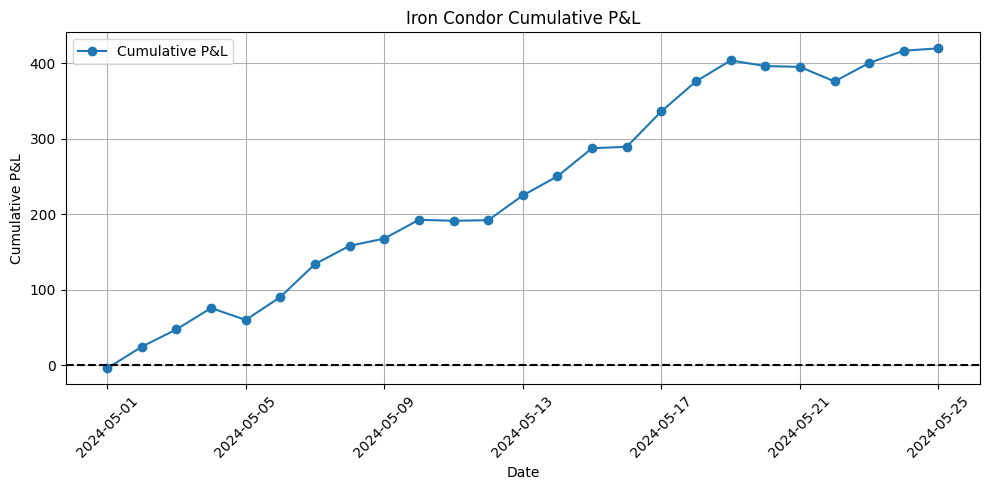

In [66]:
import matplotlib.pyplot as plt
#plot cumulative P&L
plt.figure(figsize=(10, 5))
plt.plot(result['date'], result['pnl'].cumsum(), marker='o', label='Cumulative P&L')
plt.axhline(0, color='black', linestyle='--')
plt.title('Iron Condor Cumulative P&L')
plt.xlabel('Date')
plt.ylabel('Cumulative P&L')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [68]:
%pip install pandas_datareader

Note: you may need to restart the kernel to use updated packages.Collecting pandas_datareader
  Using cached pandas_datareader-0.10.0-py3-none-any.whl.metadata (2.9 kB)
Using cached pandas_datareader-0.10.0-py3-none-any.whl (109 kB)




[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [70]:
from math import log, sqrt, pi, exp
from scipy.stats import norm
from datetime import datetime, date
import numpy as np
import dateutil
import pandas_datareader.data as web

import pandas as pd
from pandas import DataFrame

def d1(S,K,T,r,sigma):
    return(log(S/K)+(r+(sigma**2)/2.0)*T)/(sigma*sqrt(T))
def d2(S,K,T,r,sigma):
    return d1(S,K,T,r,sigma)-sigma*sqrt(T)


def bs_call(S, K, T, r, sigma):
    return S * norm.cdf(d1(S, K, T, r, sigma)) - K * exp(-r * T) * norm.cdf(d2(S, K, T, r, sigma))
def bs_put(S, K, T, r, sigma):
    #return K * exp(-r * T) * norm.cdf(-d2(S, K, T, r, sigma)) - S * norm.cdf(-d1(S, K, T, r, sigma))
    return K * exp(-r * T) - S + bs_call(S, K, T, r, sigma)

def orgDataReturns(df, date):
    df = df.loc['1982-04-20':date]
    #print(df)
    df = df.sort_values(by="Date")
    df = df.dropna()
    df = df.assign(close_day_before=df.Close.shift(1))
    df['returns'] = ((df.Close - df.close_day_before)/df.close_day_before)

    return df['returns']

def getCall(df, date, expiry, strikePrice):
    dfReturns = orgDataReturns(df, date)
    curDate = datetime.strptime(date, '%Y-%m-%d')#dateutil.parse(date)

    sigma = np.sqrt(252) * dfReturns.std()
    uty = web.DataReader(
        "^TNX", 'yahoo', curDate.replace(day=curDate.day - 1), curDate)['Close'].iloc[-1]
    lcp = df['Close'].iloc[-1]
    t = (datetime.strptime(expiry, "%Y-%m-%d") - curDate).days/365

    print('vars for black scholes')
    print(lcp, strikePrice, t, uty, sigma)
    return bs_call(lcp, strikePrice, t, uty, sigma)

def getPut(df, date, expiry, strikePrice):
    dfReturns = orgDataReturns(df, date)
    curDate = datetime.strptime(date, '%Y-%m-%d')#dateutil.parse(date)

    sigma = np.sqrt(252) * dfReturns.std()
    uty = web.DataReader(
        "^TNX", 'yahoo', curDate.replace(day=curDate.day - 1), curDate)['Close'].iloc[-1]
    lcp = df['Close'].iloc[-1]
    t = (datetime.strptime(expiry, "%Y-%m-%d") - curDate).days/365

    print('vars for black scholes')
    print(lcp, strikePrice, t, uty, sigma)
    return bs_put(lcp, strikePrice, t, uty, sigma)

In [73]:
print('program started...')

import datetime
import pandas as pd
import pandas_datareader.data as web
import numpy as np
import math
import matplotlib.pyplot as plt

start = datetime.datetime(2017, 1, 1)
end = datetime.datetime(2023, 12, 31)

dfSPY = web.DataReader('^GSPC', 'yahoo', start, end)


#print(dfSPY)
print('trying to graph')

x = np.linspace(0, 20, 100)  # Create a list of evenly-spaced numbers over the range
plt.plot(x, np.sin(x))       # Plot the sine of each x point
plt.show()                   # Display the plot

#print(BlackScholesModel.orgDataReturns(dfSPY, '1982-04-28'))
print(getCall(dfSPY, '2021-03-18', '2021-03-22', 3810))

myPercentChangeThresholdLow = -0.03
myPercentChangeThresholdHigh = 0.03
myDayRange = 3

def date_by_adding_business_days(from_date, add_days):
    business_days_to_add = add_days
    current_date = from_date
    while business_days_to_add > 0:
        current_date += datetime.timedelta(days=1)
        weekday = current_date.weekday()
        if weekday >= 5: # sunday = 6
            continue
        business_days_to_add -= 1
    return current_date

def myAddBusinessDays(date, days):
    curDate = datetime.datetime.strptime(date, '%Y-%m-%d')
    newDate = date_by_adding_business_days(curDate, days)
    return str(newDate).split()[0]

def functionToOptions(function, expiration):
    options = []
    #the function will take on the following characteristic
    #[(strikePrice, slope), (strikePrice, slope) ..., (strikePrice, slope)]
    #if strike price is None, then on left side
    #first 2 strike prices repeat
    #first node is put
    index = 0
    for node in function:
        nodeStrikePrice = node[0]
        nodeSlope = node[1]
        if index == 0:
            print('0')
            options.append([nodeSlope, 'put', expiration, nodeStrikePrice])
        elif index == 1:
            print('1)')
            options.append([nodeSlope, 'call', expiration, nodeStrikePrice])
        else:
            print('2')
            prevNodeSlope = function[index - 1][1]
            options.append([nodeSlope - prevNodeSlope, 'call', expiration, nodeStrikePrice])
        index += 1
    return options


def optionsValue(SPYPrice, curDate, options):
    #the value of a function is also the cost to close it
    #cost to close can be negative, which shows person will get money to close this
    #each function in functions will be tuple with 3 characteristics: [contractAmount, putOrCall, expiration, strike price]
    costToOpen = 0
    for options in options:
        contractAmount, putOrCall, daysToExpiration, strikePrice = options[0], options[1], options[2], options[3]
        print(curDate)
        #print('addbusiness days', myAddBusinessDays(curDate, daysToExpiration))
        if putOrCall == 'call':
            costToOpen += contractAmount*getCall(dfSPY, curDate, myAddBusinessDays(curDate, daysToExpiration), strikePrice)
        elif putOrCall == 'put':
            costToOpen += contractAmount*getPut(dfSPY, curDate, myAddBusinessDays(curDate, daysToExpiration), strikePrice)
        else:
            print('invalid option type')
        print('hi')
    return costToOpen

def graphFunction(function, SPYPrice, curDate, daysToExpiration):
    options = functionToOptions(function, daysToExpiration)
    costToOpen = optionsValue(SPYPrice, curDate, options)
    notablePoints = []
    strikeRange = function[-1][0] - function[0][0]

    nodenum = 1
    currentProfit = costToOpen
    for node in function[1:]:
        nodeStrikePrice = node[0]
        nodeSlope = node[1]
        prevNode = function[nodenum-1]
        prevNodeStrikePrice = prevNode[0]
        prevNodeSlope = prevNode[1]

        if nodenum == 1:
            notablePoints.append([nodeStrikePrice, currentProfit])
        elif False:
            pass
        else:
            currentProfit += prevNodeSlope*(nodeStrikePrice-prevNodeStrikePrice)
            notablePoints.append([nodeStrikePrice, currentProfit])

        nodenum+=1
    #for the extra point on right side
    extraPointDist = strikeRange/4
    notablePoints.append([function[-1][0] + extraPointDist, notablePoints[-1][1] + extraPointDist*function[-1][1]])
    #extra point on left
    notablePoints.insert(0, [function[0][0] - extraPointDist, notablePoints[0][1] - extraPointDist*function[0][1]])

    #convert the notable points into 2 lists
    convertedNotablePoints = [[point[0] for point in notablePoints], [point[1] for point in notablePoints]]
    print(notablePoints)
    print('\n\n\n')
    plt.plot(convertedNotablePoints[0], convertedNotablePoints[1], '-bo')
    plt.show()


print(functionToOptions([[300, -1], [300, 0], [400, 2], [500, 1]], 5))
myFunction = [[350, 0], [350, 1], [390, -1], [440, 0]]
myOptions = functionToOptions([[350, 0], [350, 1], [390, -1], [430, 0]], 5)
graphFunction(myFunction, 4000, '2021-03-18', 5)
print('cost to open', optionsValue(390, '2021-03-18', myOptions))

def getPerformance(percentChangeThresholdLow, percentChangeThresholdHigh, dayRange):
    aboveThresholdCount = 0
    curNetVal = 0

    lcp = 3915.4599609375
    print('business', myAddBusinessDays('2021-03-18', 2))

    #puts are behaving wierdly
    longPutVal = getPut(dfSPY, '2021-03-15', myAddBusinessDays('2021-03-15', dayRange), math.floor(lcp*(1+percentChangeThresholdLow)/10)*10)
    print('longPutVal', longPutVal)
    shortPutVal = getPut(dfSPY, '2021-03-15', myAddBusinessDays('2021-03-15', dayRange), math.ceil(lcp*(1+percentChangeThresholdLow)/10)*10)
    print('shortPutVal', shortPutVal)
    shortCallVal = getCall(dfSPY, '2021-03-15', myAddBusinessDays('2021-03-15', dayRange), math.floor(lcp*(1+percentChangeThresholdHigh)/10)*10)
    print('shortCallVal', shortCallVal)
    longCallVal = getCall(dfSPY, '2021-03-15', myAddBusinessDays('2021-03-15', dayRange), math.ceil(lcp*(1+percentChangeThresholdHigh)/10)*10)
    print('longCallVal', longCallVal)
    print(getPut(dfSPY, '2021-03-15', myAddBusinessDays('2021-03-15', dayRange), 5000))

    credit = (shortPutVal + shortCallVal - longPutVal - longCallVal)*10
    print(longPutVal, shortPutVal, shortCallVal, longCallVal)
    print('credit', credit)

    for index,row in dfSPY.head(len(dfSPY) - dayRange + 1).iterrows():
        #index = str(index).split()[0]
        #print(index)

        #print('\nDay', index)

        high = row['High']
        low = row['Low']
        open = row['Open']
        close = row['Close']

        for dayNum in range(dayRange):
            #curDate = datetime.datetime.strptime(str(index), '%Y-%m-%d')
            #i = curDate.replace(day=curDate.day + dayNum)
            i = np.where(dfSPY.index == index)[0][0] + dayNum
            #print(i, 'i')
            thisRow = dfSPY.iloc[i]
            if thisRow['High'] > high:
                high = thisRow['High']
            if thisRow['Low'] > low:
                low = thisRow['Low']

        percentChangeLow = low/open - 1
        percentChangeHigh = high/open - 1

        #print('business', myAddBusinessDays('2021-03-18', 2))



        if percentChangeLow < percentChangeThresholdLow or percentChangeHigh > percentChangeThresholdHigh:
            aboveThresholdCount += 1
            curNetVal += - 50
        else:
            curNetVal += credit




    print('threshold(s) passed ',aboveThresholdCount, 'out of around 10140 trading days')
    print('accuracy:', 1 - aboveThresholdCount/10140)
    print(curNetVal/10140, 'average dollars gained per day')

getPerformance(myPercentChangeThresholdLow, myPercentChangeThresholdHigh, myDayRange)
print('program ended...')

program started...


RemoteDataError: Unable to read URL: https://finance.yahoo.com/quote/^GSPC/history?period1=1483223400&period2=1704061799&interval=1d&frequency=1d&filter=history
Response Text:
b'<html><meta charset=\'utf-8\'><script>if(window!=window.top){document.write(\'<p>Content is currently unavailable.</p><img src="//geo.yahoo.com/p?s=1197757039&t=\'+new Date().getTime()+\'&_R=\'+encodeURIComponent(document.referrer)+\'&err=404&err_url=\'+\'https%3A%2F%2Fbrb.yahoo.net%3A443%2Ffinance.yahoo.com%2Fdesktop%2Fquote%2F%255EGSPC%2Fhistory%2Findex.html\'+\'" width="0px" height="0px"/>\');}else{window.location.replace(\'https://www.yahoo.com/?err=404&err_url=https%3A%2F%2Fbrb.yahoo.net%3A443%2Ffinance.yahoo.com%2Fdesktop%2Fquote%2F%255EGSPC%2Fhistory%2Findex.html\');}</script><noscript><META http-equiv="refresh" content="0;URL=\'https://www.yahoo.com/?err=404&err_url=https%3A%2F%2Fbrb.yahoo.net%3A443%2Ffinance.yahoo.com%2Fdesktop%2Fquote%2F%255EGSPC%2Fhistory%2Findex.html\'"></noscript></html>'